# 📌 Outlier Detection using IQR (Interquartile Range) and Box Plot

## 🎯 Objective

In this notebook, we will learn how to detect and handle outliers using the **Interquartile Range (IQR) Method** and **Box Plot**.

---

## 📚 What is IQR?

The **Interquartile Range (IQR)** measures the spread of the middle **50%** of the data.

It is calculated as:

**IQR = Q3 - Q1**

where:

- **Q1 (First Quartile)** = 25th Percentile
- **Q2 (Median)** = 50th Percentile
- **Q3 (Third Quartile)** = 75th Percentile

---

## 📌 Outlier Detection Rule

A value is considered an outlier if:

- **Value < Q1 - 1.5 × IQR**
- **Value > Q3 + 1.5 × IQR**

Unlike the Z-Score method, IQR **does not assume the data follows a normal distribution**, making it suitable for skewed datasets.

---

## 🎯 Goals of this Notebook

- Import the required libraries
- Load the Titanic dataset
- Visualize outliers using a Box Plot
- Calculate Q1, Q3, and IQR
- Detect outliers
- Remove outliers (Trimming)
- Cap outliers (Capping)
- Compare the dataset before and after handling outliers



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv('train.csv')

In [4]:
df = df[['Age']]
df = df.dropna()
df.head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


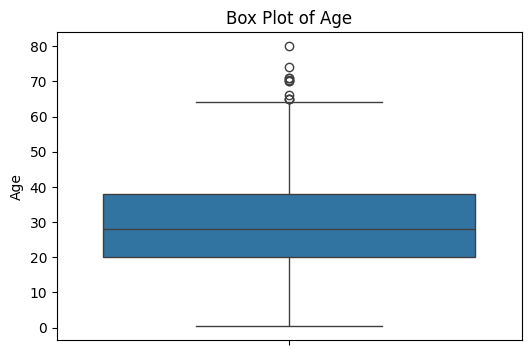

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Age'])
plt.title("Box Plot of Age")
plt.show()

In [6]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 20.125
Q3: 38.0


In [7]:
IQR = Q3 - Q1
print("IQR:", IQR)

IQR: 17.875


In [8]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -6.6875
Upper Limit: 64.8125


In [9]:
df[(df['Age'] < lower_limit) | (df['Age'] > upper_limit)]

,Age
33,66.0
54,65.0
96,71.0
116,70.5
280,65.0
456,65.0
493,71.0
630,80.0
672,70.0
745,70.0


In [10]:
df_trimmed = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

In [11]:
print("Original Shape:", df.shape)
print("Trimmed Shape:", df_trimmed.shape)

Original Shape: (714, 1)
Trimmed Shape: (703, 1)


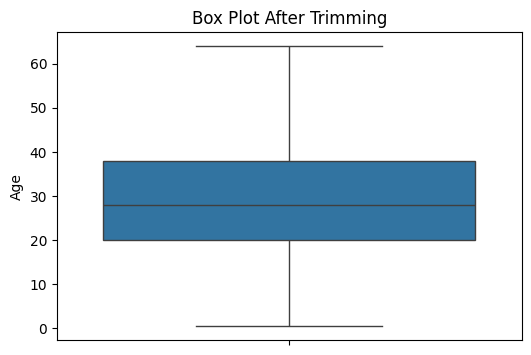

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_trimmed['Age'])
plt.title("Box Plot After Trimming")
plt.show()

In [13]:
df_capped = df.copy()

df_capped['Age'] = np.where(
    df_capped['Age'] < lower_limit,
    lower_limit,
    np.where(
        df_capped['Age'] > upper_limit,
        upper_limit,
        df_capped['Age']
    )
)

In [14]:
print("Maximum Before:", df['Age'].max())
print("Maximum After :", df_capped['Age'].max())

print("Minimum Before:", df['Age'].min())
print("Minimum After :", df_capped['Age'].min())

Maximum Before: 80.0
Maximum After : 64.8125
Minimum Before: 0.42
Minimum After : 0.42


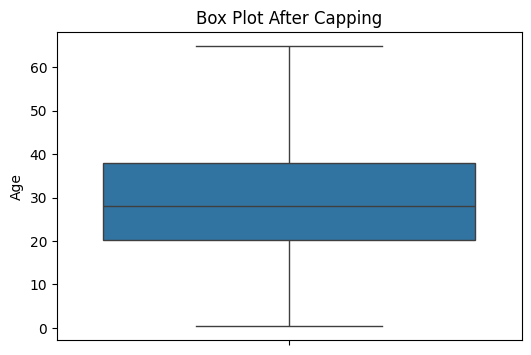

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_capped['Age'])
plt.title("Box Plot After Capping")
plt.show()